In [2]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

1. Data (preparing and loading)

In [3]:
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)


(40, 40, 10, 10)

In [8]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

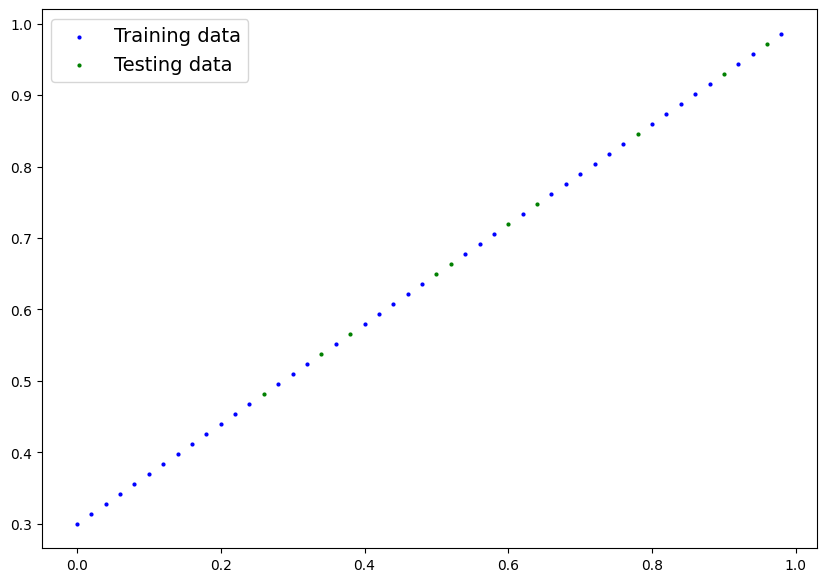

In [9]:

plot_predictions()


2. Build model

In [10]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias=nn.Parameter(torch.randn(1,dtype=torch.float,requires_grad=True))

    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights*x +self.bias

In [11]:
model=LinearRegressionModel()
list(model.parameters())

[Parameter containing:
 tensor([0.1996], requires_grad=True),
 Parameter containing:
 tensor([0.8076], requires_grad=True)]

In [13]:
with torch.inference_mode(): 
    y_preds = model(X_test)
y_preds

tensor([[0.8595],
        [0.9632],
        [0.9273],
        [0.9872],
        [0.8754],
        [0.9992],
        [0.9114],
        [0.9074],
        [0.9353],
        [0.8834]])


3. Train model

In [14]:
loss_fn = nn.L1Loss() 
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [15]:
torch.manual_seed(42)

epochs=100

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model.train()

    y_pred=model(X_train)

    loss=loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")


Epoch: 0 | MAE Train Loss: 0.27463454008102417 | MAE Test Loss: 0.20059314370155334 
Epoch: 10 | MAE Train Loss: 0.19339044392108917 | MAE Test Loss: 0.13494117558002472 
Epoch: 20 | MAE Train Loss: 0.16592571139335632 | MAE Test Loss: 0.11456789076328278 
Epoch: 30 | MAE Train Loss: 0.15406332910060883 | MAE Test Loss: 0.10292541980743408 
Epoch: 40 | MAE Train Loss: 0.14533847570419312 | MAE Test Loss: 0.0972708910703659 
Epoch: 50 | MAE Train Loss: 0.13798487186431885 | MAE Test Loss: 0.09454488009214401 
Epoch: 60 | MAE Train Loss: 0.13185301423072815 | MAE Test Loss: 0.09123043715953827 
Epoch: 70 | MAE Train Loss: 0.12608738243579865 | MAE Test Loss: 0.08770544826984406 
Epoch: 80 | MAE Train Loss: 0.12042592465877533 | MAE Test Loss: 0.08392664045095444 
Epoch: 90 | MAE Train Loss: 0.11484865099191666 | MAE Test Loss: 0.08004634082317352 


In [16]:
print("The model learned the following values for weights and bias:")
print(model.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.2930])), ('bias', tensor([0.5196]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


4. Making predictions with a trained PyTorch model (inference)